# Bitcoin Market Regime Classification & Return Prediction

## 1. Project Setup

We import the Python libraries required for data acquisition, data preparation, exploratory analysis, feature engineering, and modeling.

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

## 2. Data Acquisition

We download daily Bitcoin (BTC-USD) market data from Yahoo Finance using the yfinance library. The dataset includes opening price, highest price, lowest price, closing price, and trading volume.

In [2]:
btc = yf.download(
    "BTC-USD",
    start="2017-01-01",
    end="2026-09-25",
    interval="1d"
)

[*********************100%***********************]  1 of 1 completed


## 3. Initial Dataset Inspection

We inspect the first and last observations and the dimensions of the dataset to verify that the download was successful and understand its basic structure.

In [3]:
print(btc.head())
print(btc.tail())
print(btc.shape)

Price             Close         High          Low         Open     Volume
Ticker          BTC-USD      BTC-USD      BTC-USD      BTC-USD    BTC-USD
Date                                                                     
2017-01-01   998.325012  1003.080017   958.698975   963.658020  147775008
2017-01-02  1021.750000  1031.390015   996.702026   998.617004  222184992
2017-01-03  1043.839966  1044.079956  1021.599976  1021.599976  185168000
2017-01-04  1154.729980  1159.420044  1044.400024  1044.400024  344945984
2017-01-05  1013.380005  1191.099976   910.416992  1156.729980  510199008
Price              Close          High           Low          Open  \
Ticker           BTC-USD       BTC-USD       BTC-USD       BTC-USD   
Date                                                                 
2026-09-20  81142.609375  81455.203125  80098.773438  81234.304688   
2026-09-21  86602.914062  87363.757812  80867.085938  81143.625000   
2026-09-22  86172.281250  86700.000000  85098.007812  8660

## 4. Data Quality Check

We check for missing values, duplicate dates, and the data types of each variable.
This helps determine whether the dataset requires cleaning before further analysis.

In [4]:
print("Missing values:")
print(btc.isna().sum())

print("\nDuplicate dates:")
print(btc.index.duplicated().sum())

print("\nData types:")
print(btc.dtypes)

Missing values:
Price   Ticker 
Close   BTC-USD    0
High    BTC-USD    0
Low     BTC-USD    0
Open    BTC-USD    0
Volume  BTC-USD    0
dtype: int64

Duplicate dates:
0

Data types:
Price   Ticker 
Close   BTC-USD    float64
High    BTC-USD    float64
Low     BTC-USD    float64
Open    BTC-USD    float64
Volume  BTC-USD      int64
dtype: object


## 5. Data Preparation

The downloaded dataset contains a two-level column structure because yfinance identifies both the price field and the ticker symbol. Since this project uses only BTC-USD, we simplify the column structure before performing further analysis.

In [5]:
btc.columns = btc.columns.get_level_values(0)

print(btc.head())

Price             Close         High          Low         Open     Volume
Date                                                                     
2017-01-01   998.325012  1003.080017   958.698975   963.658020  147775008
2017-01-02  1021.750000  1031.390015   996.702026   998.617004  222184992
2017-01-03  1043.839966  1044.079956  1021.599976  1021.599976  185168000
2017-01-04  1154.729980  1159.420044  1044.400024  1044.400024  344945984
2017-01-05  1013.380005  1191.099976   910.416992  1156.729980  510199008


## 6. OHLC Consistency Check

We verify that the daily high and low prices are consistent with the opening and closing prices. For each observation, the high should be at least as large as both the open and close, while the low should be no greater than either.

In [6]:
high_violations = (
    (btc["High"] < btc["Open"]) |
    (btc["High"] < btc["Close"])
).sum()

low_violations = (
    (btc["Low"] > btc["Open"]) |
    (btc["Low"] > btc["Close"])
).sum()

print("High-price violations:", high_violations)
print("Low-price violations:", low_violations)

High-price violations: 0
Low-price violations: 0


## 7. Date Continuity Check

Because Bitcoin trades continuously throughout the week, the dataset should contain one daily observation for every calendar day in the period. We check that the date index has no gaps.

In [7]:
expected_dates = pd.date_range(
    start=btc.index.min(),
    end=btc.index.max(),
    freq="D"
)

missing_dates = expected_dates.difference(btc.index)

print("Expected observations:", len(expected_dates))
print("Actual observations:", len(btc))
print("Missing dates:", len(missing_dates))

Expected observations: 3554
Actual observations: 3554
Missing dates: 0


## 8. Exploratory Data Analysis

We begin by examining the evolution of Bitcoin's closing price over the full sample period. This provides an initial view of major trends, periods of rapid price appreciation or decline, and changes in market behavior that may correspond to different market regimes.

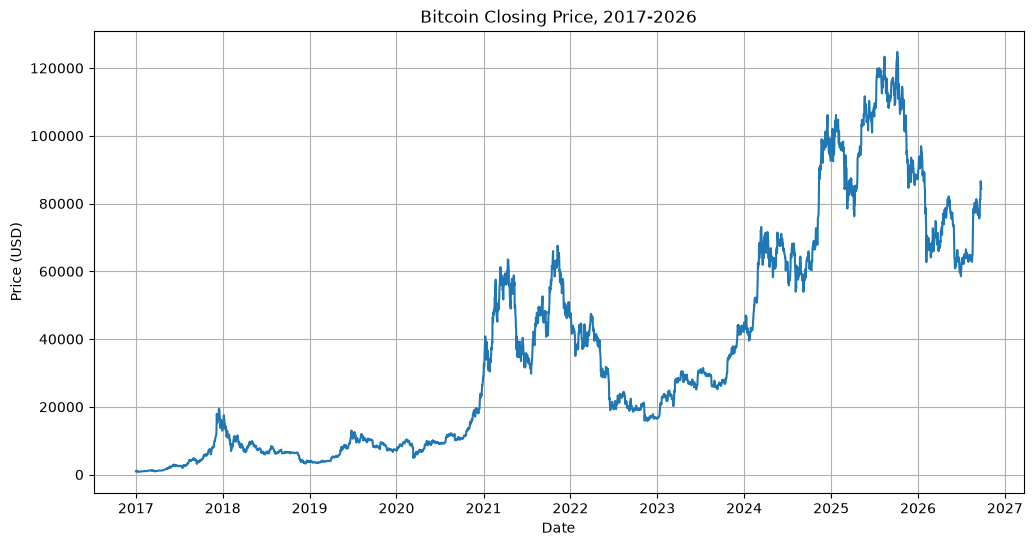

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(btc.index, btc["Close"])

plt.title("Bitcoin Closing Price, 2017-2026")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)

plt.show()

## 9. Return Analysis

Because market regimes are characterized by changes in performance and risk rather than price level alone, we calculate daily percentage returns from the closing price. Returns provide a scale-independent measure of Bitcoin's daily price movement.

In [9]:
btc["Daily_Return"] = btc["Close"].pct_change()

print(btc["Daily_Return"].describe())

count    3553.000000
mean        0.001878
std         0.035347
min        -0.371695
25%        -0.013523
50%         0.000976
75%         0.016315
max         0.252472
Name: Daily_Return, dtype: float64


## 10. Daily Return Distribution

We examine the distribution of daily Bitcoin returns to assess its central tendency, dispersion, and the presence of extreme observations. This helps characterize the risk and variability of the market before constructing volatility-based regime features.

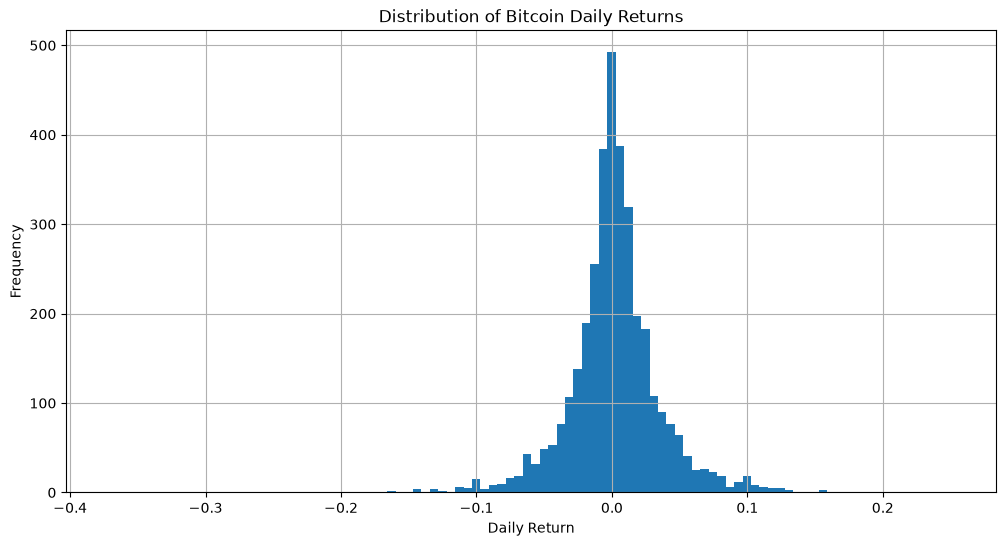

In [10]:
plt.figure(figsize=(12, 6))

plt.hist(btc["Daily_Return"].dropna(), bins=100)

plt.title("Distribution of Bitcoin Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

## 11. Rolling Volatility

We calculate rolling volatility to measure how the variability of Bitcoin's daily returns changes over time. A 30-day rolling standard deviation provides a short-term measure of market risk and may help distinguish periods of relatively low and high volatility.

In [11]:
btc["Volatility_30d"] = btc["Daily_Return"].rolling(window=30).std()

print(btc["Volatility_30d"].describe())

count    3524.000000
mean        0.032077
std         0.014257
min         0.008887
25%         0.022258
50%         0.028744
75%         0.038535
max         0.091330
Name: Volatility_30d, dtype: float64


## 12. Rolling Volatility Over Time

We visualize the 30-day rolling volatility to identify periods of relatively low and high market variability throughout the sample.

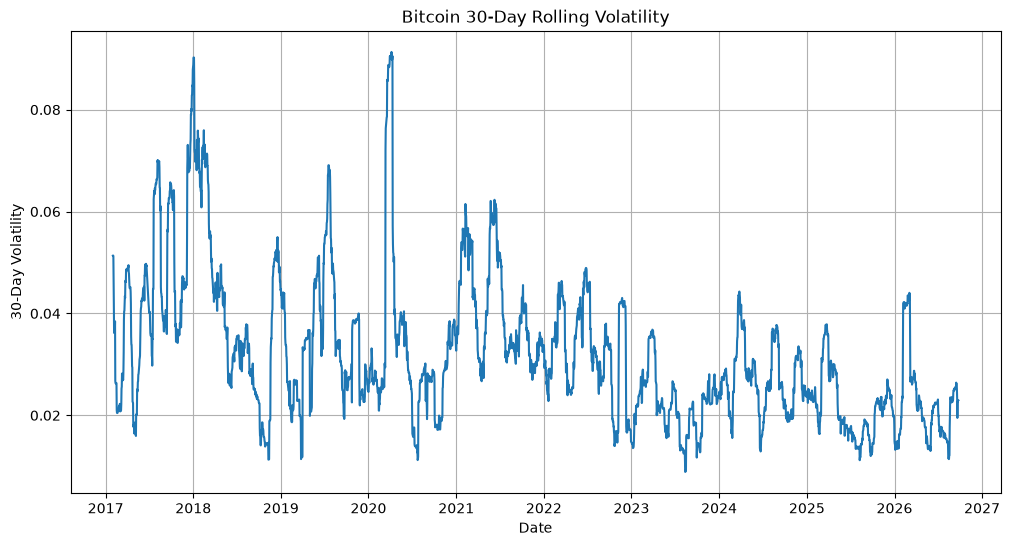

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(btc.index, btc["Volatility_30d"])

plt.title("Bitcoin 30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("30-Day Volatility")
plt.grid(True)

plt.show()

## 13. Rolling Return

We calculate the 30-day rolling mean of daily returns to capture the recent directional tendency of the Bitcoin market. Combined with rolling volatility, this provides information about both market direction and market variability.

In [13]:
btc["Return_30d"] = btc["Daily_Return"].rolling(window=30).mean()

print(btc["Return_30d"].describe())

count    3524.000000
mean        0.001893
std         0.007090
min        -0.028166
25%        -0.002183
50%         0.001116
75%         0.005898
max         0.038491
Name: Return_30d, dtype: float64


## 14. Rolling Return Over Time

We visualize the 30-day rolling mean of daily returns to identify periods of relatively positive and negative market direction over time.

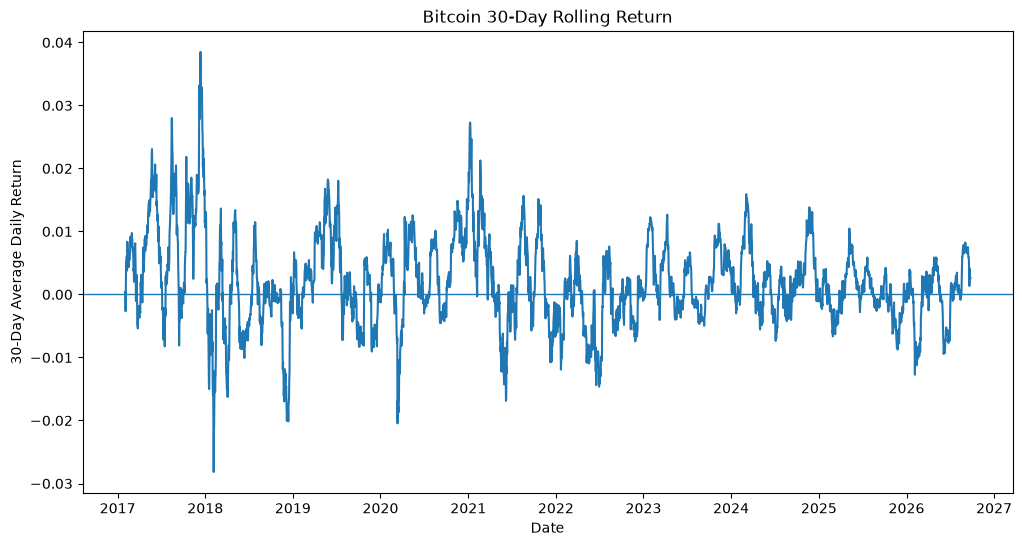

In [14]:
plt.figure(figsize=(12, 6))

plt.plot(btc.index, btc["Return_30d"])

plt.axhline(0, linewidth=1)

plt.title("Bitcoin 30-Day Rolling Return")
plt.xlabel("Date")
plt.ylabel("30-Day Average Daily Return")

plt.show()

## 15. Relationship Between Rolling Return and Volatility

We examine the relationship between recent market direction and volatility. This helps determine whether periods of positive or negative returns tend to occur alongside different levels of market variability.

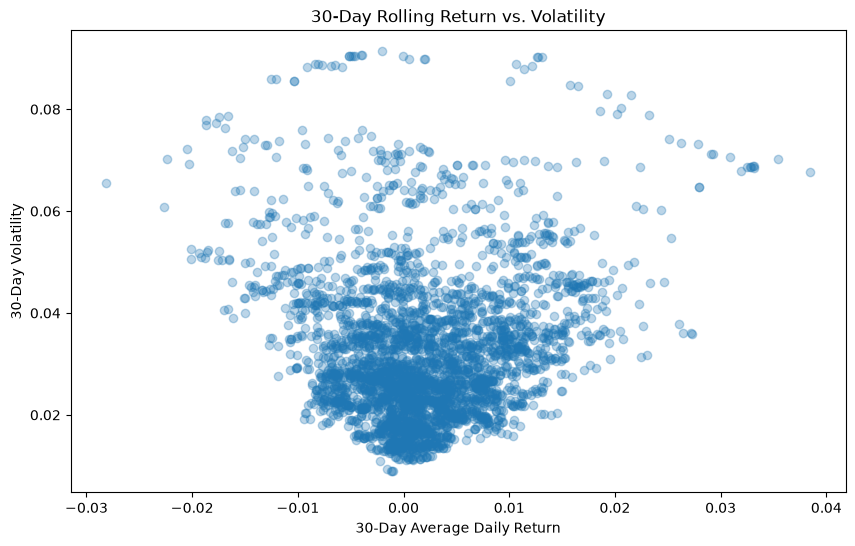

In [15]:
plt.figure(figsize=(10, 6))

plt.scatter(
    btc["Return_30d"],
    btc["Volatility_30d"],
    alpha=0.3
)

plt.title("30-Day Rolling Return vs. Volatility")
plt.xlabel("30-Day Average Daily Return")
plt.ylabel("30-Day Volatility")

plt.show()

## 16. Prepare Data for Regime Identification

We prepare the variables that will be used to identify market regimes. The first observations contain missing rolling features because a complete 30-day window is not yet available, so these observations are excluded from the regime analysis.

In [16]:
regime_data = btc[["Return_30d", "Volatility_30d"]].dropna()

print("Observations available for regime identification:", len(regime_data))
print("Missing values:")
print(regime_data.isna().sum())

Observations available for regime identification: 3524
Missing values:
Price
Return_30d        0
Volatility_30d    0
dtype: int64


## 17. Standardize Regime Features

We standardize the rolling return and rolling volatility features so that both variables contribute comparably to the regime identification process. Standardization transforms each feature to have a mean of approximately zero and a standard deviation of one.

In [17]:
scaler = StandardScaler()

regime_scaled = pd.DataFrame(
    scaler.fit_transform(regime_data),
    columns=regime_data.columns,
    index=regime_data.index
)

print(regime_scaled.describe())

Price    Return_30d  Volatility_30d
count  3.524000e+03    3.524000e+03
mean  -4.839111e-17    1.290429e-16
std    1.000142e+00    1.000142e+00
min   -4.240305e+00   -1.626778e+00
25%   -5.749336e-01   -6.888211e-01
50%   -1.095187e-01   -2.338166e-01
75%    5.650800e-01    4.530293e-01
max    5.162818e+00    4.156550e+00


## 18. Determine the Number of Market Regimes

We evaluate several candidate numbers of clusters using K-Means clustering. Inertia and silhouette scores are used together to assess the compactness and separation of the resulting clusters. This allows the number of market regimes to be selected based on the structure of the data rather than being imposed arbitrarily.

In [18]:
inertia = []
silhouette_scores = []

k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(regime_scaled)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(regime_scaled, labels))

print("K values:", list(k_values))
print("Inertia:", inertia)
print("Silhouette scores:", silhouette_scores)

K values: [2, 3, 4, 5, 6, 7, 8]
Inertia: [4633.714948343315, 2979.4994445125367, 2373.5425285729675, 1911.0838122687794, 1645.886474318118, 1393.166829181683, 1214.3909565465651]
Silhouette scores: [0.42017247026629756, 0.43757185929426745, 0.364813510324076, 0.3687438956566324, 0.37367436862854614, 0.3649203429064462, 0.3652933099081207]


### Cluster Evaluation

We visualize inertia and silhouette scores across different numbers of clusters to identify a suitable number of market regimes.

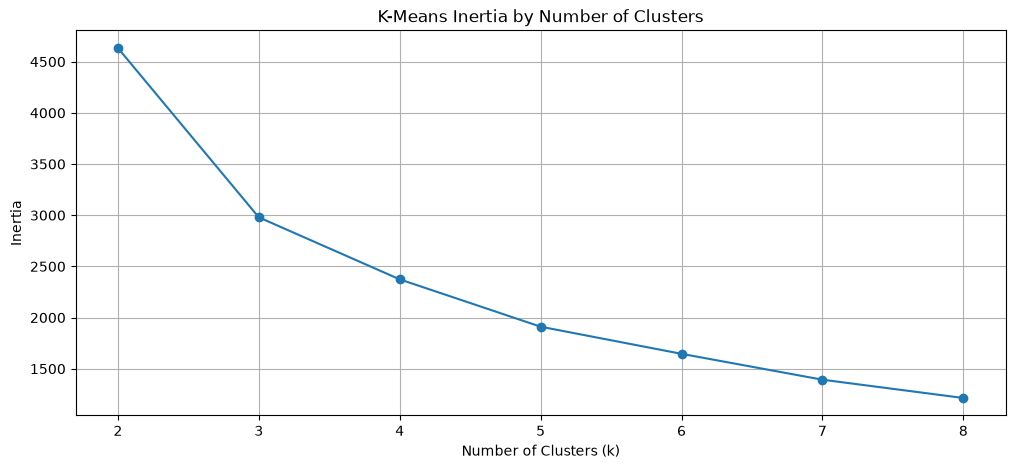

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(k_values, inertia, marker="o")

plt.title("K-Means Inertia by Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

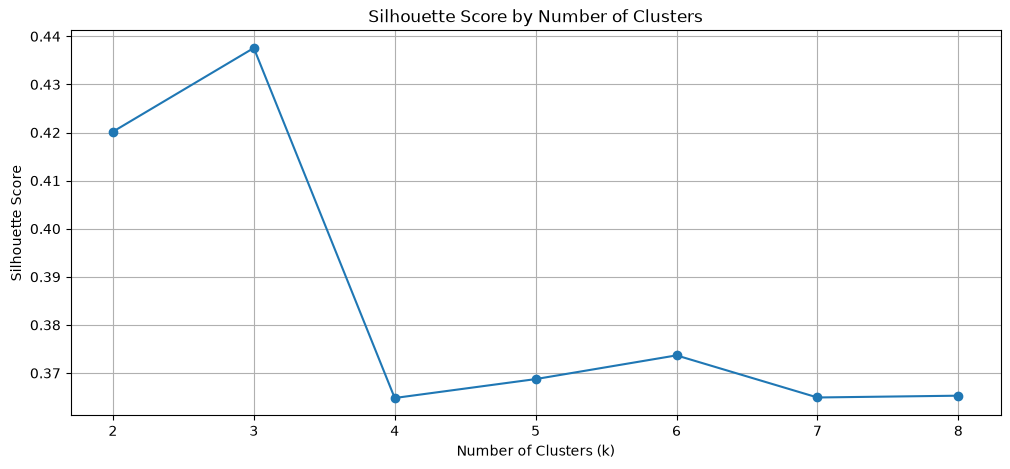

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(k_values, silhouette_scores, marker="o")

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

## 19. Fit the Final Market Regime Model

Based on the evaluation of candidate cluster counts, three clusters provide the strongest overall separation of the observations. We therefore fit the final K-Means model using three clusters to identify the market regimes present in the Bitcoin data.

The resulting cluster assignments will be used to examine the characteristics and frequency of each regime.

In [21]:
kmeans_final = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = kmeans_final.fit_predict(regime_scaled)

In [22]:
regime_labeled = regime_data.copy()
regime_labeled["Regime"] = labels

## 20. Examine the Regime Characteristics

The K-Means model identifies clusters using standardized features. To interpret the resulting regimes, we transform the cluster centers back to the original scale of the 30-day average return and 30-day volatility.

This allows us to compare the typical return and volatility characteristics of each identified regime.

In [23]:
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=["Return_30d", "Volatility_30d"]
)

cluster_centers.index.name = "Regime"

cluster_centers

,Return_30d,Volatility_30d
Regime,,
0,0.011555,0.041107
1,-0.005586,0.052150
2,0.000464,0.024371


## 21. Examine Regime Frequency

We examine the number and proportion of observations assigned to each market regime. This helps determine how frequently each regime occurs over the period analyzed and provides context for interpreting the clustering results.

In [24]:
regime_counts = regime_labeled["Regime"].value_counts().sort_index()

regime_counts

Regime
0     745
1     530
2    2249
Name: count, dtype: int64

In [25]:
regime_percentages = (
    regime_labeled["Regime"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

regime_percentages

Regime
0    21.140749
1    15.039728
2    63.819523
Name: proportion, dtype: float64

## 22. Visualize the Market Regimes

We visualize the observations in terms of their 30-day average return and 30-day volatility, with each observation colored according to its assigned market regime. This provides a visual assessment of how the identified regimes are distributed across the feature space.

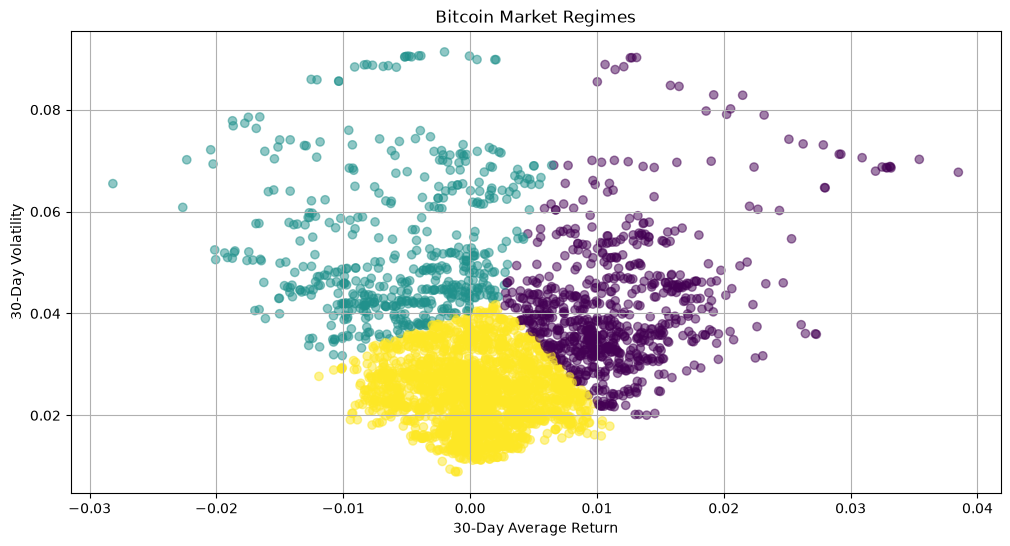

In [26]:
plt.figure(figsize=(12, 6))

plt.scatter(
    regime_labeled["Return_30d"],
    regime_labeled["Volatility_30d"],
    c=regime_labeled["Regime"],
    alpha=0.5
)

plt.xlabel("30-Day Average Return")
plt.ylabel("30-Day Volatility")
plt.title("Bitcoin Market Regimes")
plt.grid(True)
plt.show()

## 23. Interpret the Market Regimes

The cluster centers and regime distribution provide a basis for interpreting the three identified market regimes. The regimes are described according to their typical 30-day return and volatility characteristics rather than being assigned predetermined market labels.

- Regime 0 is characterized by positive 30-day average returns and relatively high volatility.
- Regime 1 is characterized by negative 30-day average returns and the highest volatility of the three regimes.
- Regime 2 is characterized by near-zero 30-day average returns and comparatively low volatility.

These characteristics suggest that the clustering captures distinct combinations of return direction and market volatility. Regime 2 is the most frequently observed regime, while Regime 1 is the least frequent.

## 24. Visualize Market Regimes Over Time

We visualize the assigned market regimes over the historical period to examine how market conditions changed through time. This helps identify periods in which each regime was more prevalent and provides temporal context for the clustering results.

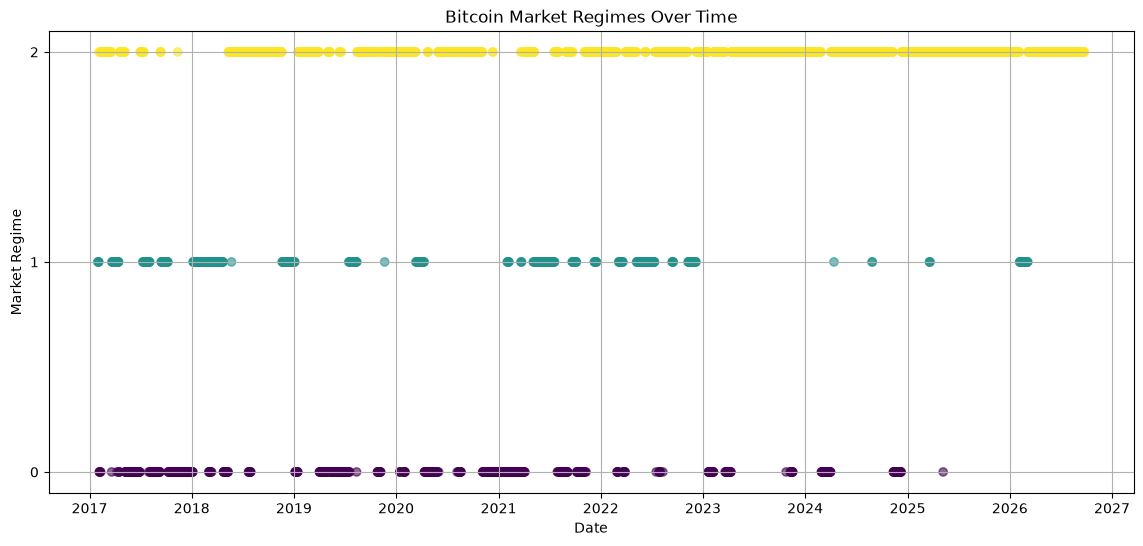

In [27]:
plt.figure(figsize=(14, 6))

plt.scatter(
    regime_labeled.index,
    regime_labeled["Regime"],
    c=regime_labeled["Regime"],
    alpha=0.6
)

plt.xlabel("Date")
plt.ylabel("Market Regime")
plt.title("Bitcoin Market Regimes Over Time")
plt.yticks([0, 1, 2])
plt.grid(True)
plt.show()

## 25. Analyze Regime Persistence

We examine how long the market remains in each identified regime before transitioning to another regime. Regime persistence provides additional information about whether the identified market conditions tend to be sustained over multiple observations or occur mainly as short-lived transitions.

In [28]:
regime_labeled["Regime_Change"] = (
    regime_labeled["Regime"] != regime_labeled["Regime"].shift()
)

In [29]:
regime_labeled["Regime_Run"] = (
    regime_labeled["Regime_Change"].cumsum()
)

In [30]:
regime_durations = (
    regime_labeled.groupby(["Regime_Run", "Regime"])
    .size()
    .reset_index(name="Duration")
)

regime_durations

,Regime_Run,Regime,Duration
0,1,1,4
1,2,2,1
2,3,0,4
3,4,2,1
4,5,0,1
...,...,...,...
151,152,2,46
152,153,0,1
153,154,2,272
154,155,1,30


In [31]:
regime_duration_summary = (
    regime_durations.groupby("Regime")["Duration"]
    .agg(["mean", "median", "min", "max", "count"])
)

regime_duration_summary

,mean,median,min,max,count
Regime,,,,,
0,13.303571,6.0,1,54,56
1,14.324324,4.0,1,69,37
2,35.698413,11.0,1,272,63


## 26. Interpret Regime Persistence

The persistence analysis shows that the three regimes differ in the duration of their uninterrupted runs. Regimes 0 and 1 have similar average durations of approximately 13 and 14 days, respectively, while Regime 2 has a substantially longer average duration of approximately 36 days.

The median durations are lower than the corresponding means for all three regimes, particularly for Regime 2. This indicates that some unusually long regime runs increase the mean duration. Regime 2 has a maximum observed duration of 272 days, which contributes substantially to its higher mean.

Overall, the results indicate that Regime 2 tends to persist for longer periods, while Regimes 0 and 1 tend to transition more frequently. These persistence characteristics provide additional information about the temporal behavior of the identified market regimes.

## 27. Define the Prediction Target

We define the prediction target as the next day's Bitcoin return. This allows us to evaluate whether information available up to the current day can help predict the following day's return.

In [32]:
btc["Next_Day_Return"] = btc["Daily_Return"].shift(-1)

In [33]:
btc[["Daily_Return", "Next_Day_Return"]].head()

Price,Daily_Return,Next_Day_Return
Date,,
2017-01-01,NaN,0.023464
2017-01-02,0.023464,0.021620
2017-01-03,0.021620,0.106233
2017-01-04,0.106233,-0.122410
2017-01-05,-0.122410,-0.109711


## 28. Create a Time-Based Train/Test Split

We divide the data chronologically into training and test sets. The training set contains earlier observations used to develop the prediction model, while the test set contains later observations reserved for evaluating out-of-sample performance.

A chronological split is used instead of a random split because future observations should not be used to predict past observations.

In [34]:
modeling_data = btc[
    ["Daily_Return", "Return_30d", "Volatility_30d", "Next_Day_Return"]
].dropna()

split_index = int(len(modeling_data) * 0.8)

train_data = modeling_data.iloc[:split_index].copy()
test_data = modeling_data.iloc[split_index:].copy()

print("Training observations:", len(train_data))
print("Test observations:", len(test_data))
print("Training period:", train_data.index.min(), "to", train_data.index.max())
print("Test period:", test_data.index.min(), "to", test_data.index.max())

Training observations: 2818
Test observations: 705
Training period: 2017-01-31 00:00:00 to 2024-10-18 00:00:00
Test period: 2024-10-19 00:00:00 to 2026-09-23 00:00:00


## 29. Fit the Regime Model on Training Data

To avoid data leakage, the regime-identification process is fitted using only the training data. The same standardization and K-Means model are then applied to the test data without refitting them.

The number of regimes is set to three based on the exploratory clustering analysis conducted earlier.

In [35]:
train_regime_features = train_data[
    ["Return_30d", "Volatility_30d"]
]

test_regime_features = test_data[
    ["Return_30d", "Volatility_30d"]
]

regime_scaler = StandardScaler()

train_regime_scaled = regime_scaler.fit_transform(
    train_regime_features
)

test_regime_scaled = regime_scaler.transform(
    test_regime_features
)

In [36]:
kmeans_model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

train_regime_labels = kmeans_model.fit_predict(
    train_regime_scaled
)

test_regime_labels = kmeans_model.predict(
    test_regime_scaled
)

## 30. Add Regime Labels to the Modeling Data

We add the regime labels generated by the training-fitted K-Means model to the training and test datasets. The training labels come from the fitted model, while the test labels are assigned using the same cluster centers without refitting the model.

In [37]:
train_data["Regime"] = train_regime_labels
test_data["Regime"] = test_regime_labels

In [38]:
train_data.head()

Price,Daily_Return,Return_30d,Volatility_30d,Next_Day_Return,Regime
Date,,,,,
2017-01-31,0.054348,0.000380,0.051335,0.019188,2
2017-02-01,0.019188,0.000238,0.051274,0.023030,2
2017-02-02,0.023030,0.000285,0.051295,0.017899,2
2017-02-03,0.017899,-0.002660,0.047390,0.012613,2
2017-02-04,0.012613,0.001841,0.041695,-0.014920,0


In [39]:
test_data.head()

Price,Daily_Return,Return_30d,Volatility_30d,Next_Day_Return,Regime
Date,,,,,
2024-10-19,-0.000819,0.002929,0.018796,0.009347,0
2024-10-20,0.009347,0.003106,0.018832,-0.023678,0
2024-10-21,-0.023678,0.002211,0.019456,-0.000096,0
2024-10-22,-0.000096,0.002074,0.019458,-0.013794,0
2024-10-23,-0.013794,0.001781,0.019633,0.026024,0


## 31. Prepare the Baseline Prediction Model

We first establish a baseline model that predicts the next day's Bitcoin return without using market-regime information. This provides a benchmark against which the regime-enhanced model can later be evaluated.

In [40]:
X_train_baseline = train_data[
    ["Daily_Return", "Return_30d", "Volatility_30d"]
]

y_train = train_data["Next_Day_Return"]

X_test_baseline = test_data[
    ["Daily_Return", "Return_30d", "Volatility_30d"]
]

y_test = test_data["Next_Day_Return"]

## 32. Train the Baseline Prediction Model

We train a Random Forest regression model using the baseline features to predict the next day's Bitcoin return. The model is trained only on the training period and will later be evaluated on the unseen test period.

In [41]:
baseline_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(X_train_baseline, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [42]:
baseline_predictions = baseline_model.predict(X_test_baseline)

## 33. Evaluate the Baseline Model

We evaluate the baseline model on the unseen test period using mean absolute error (MAE) and root mean squared error (RMSE). These metrics quantify the difference between the predicted and actual next-day Bitcoin returns.

In [43]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 0.018949143294491193
Baseline RMSE: 0.02582911842193015


In [44]:
X_train_regime = train_data[
    ["Daily_Return", "Return_30d", "Volatility_30d", "Regime"]
]

X_test_regime = test_data[
    ["Daily_Return", "Return_30d", "Volatility_30d", "Regime"]
]

regime_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

regime_model.fit(
    X_train_regime,
    y_train
)

regime_predictions = regime_model.predict(
    X_test_regime
)

## 34. Encode Regime as a Categorical Feature

The market-regime labels represent categories rather than numerical quantities. We therefore encode the three regimes as binary indicator variables before retraining the regime-enhanced model. This prevents the prediction model from interpreting the regime labels as ordered numerical values.

In [45]:
X_train_regime = train_data[
    ["Daily_Return", "Return_30d", "Volatility_30d"]
].copy()

X_test_regime = test_data[
    ["Daily_Return", "Return_30d", "Volatility_30d"]
].copy()

for regime in [0, 1, 2]:
    X_train_regime[f"Regime_{regime}"] = (
        train_data["Regime"] == regime
    ).astype(int)

    X_test_regime[f"Regime_{regime}"] = (
        test_data["Regime"] == regime
    ).astype(int)

## 35. Train the Regime-Enhanced Prediction Model
We retrain the Random Forest model using the baseline features together with the one-hot encoded regime indicators. The model is trained on the same training period as the baseline model so that the two approaches can be compared fairly.

In [46]:
regime_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

regime_model.fit(
    X_train_regime,
    y_train
)

regime_predictions = regime_model.predict(
    X_test_regime
)

## 36. Evaluate the Regime-Enhanced Model
We evaluate the regime-enhanced model on the same unseen test period using mean absolute error (MAE) and root mean squared error (RMSE). These results can be compared directly with the baseline model to determine whether adding regime information improves out-of-sample prediction.

In [47]:
regime_mae = mean_absolute_error(
    y_test,
    regime_predictions
)

regime_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        regime_predictions
    )
)

print("Regime-Enhanced MAE:", regime_mae)
print("Regime-Enhanced RMSE:", regime_rmse)

Regime-Enhanced MAE: 0.01901354838516901
Regime-Enhanced RMSE: 0.02597177309909588


## 37. Compare Model Performance

We compare the baseline and regime-enhanced models using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

Lower values indicate better predictive performance. The comparison allows us to determine whether adding market-regime information improves out-of-sample prediction of the next day's Bitcoin return.

In [48]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Regime-Enhanced"],
    "MAE": [baseline_mae, regime_mae],
    "RMSE": [baseline_rmse, regime_rmse]
})

comparison

,Model,MAE,RMSE
0,Baseline,0.018949,0.025829
1,Regime-Enhanced,0.019014,0.025972


In [49]:
mae_change = (regime_mae - baseline_mae) / baseline_mae * 100
rmse_change = (regime_rmse - baseline_rmse) / baseline_rmse * 100

print(f"MAE change: {mae_change:.2f}%")
print(f"RMSE change: {rmse_change:.2f}%")

MAE change: 0.34%
RMSE change: 0.55%


## 38. Summary of Main Results

The analysis identified three distinct Bitcoin market regimes using 30-day average returns and 30-day volatility.

Regime 0 was characterized by positive average returns and relatively high volatility. Regime 1 had negative average returns and the highest volatility, while Regime 2 had near-zero average returns and comparatively low volatility.

The regimes also differed in persistence. Regime 2 tended to persist for longer periods, with an average duration of approximately 36 days, compared with approximately 13 days for Regime 0 and 14 days for Regime 1.

For next-day return prediction, the baseline Random Forest model achieved an MAE of 0.018949 and an RMSE of 0.025829 on the out-of-sample test period. The regime-enhanced model achieved an MAE of 0.019014 and an RMSE of 0.025972.

Adding regime information therefore did not improve predictive performance. MAE increased by approximately 0.34% and RMSE increased by approximately 0.55% relative to the baseline model. The results suggest that the identified regimes provide descriptive information about market conditions, but do not provide meaningful additional predictive information for next-day Bitcoin returns beyond the existing return and volatility features used in this modeling approach.

## 39. Conclusions

This analysis identified three distinct Bitcoin market regimes based on 30-day average returns and 30-day volatility. The regimes showed meaningful differences in their return and volatility characteristics, as well as in their persistence over time. This suggests that the clustering approach can provide a useful descriptive framework for distinguishing different historical market conditions.

However, incorporating the identified regimes into a Random Forest model did not improve next-day Bitcoin return prediction. The regime-enhanced model produced slightly higher MAE and RMSE than the baseline model on the out-of-sample test period. This indicates that the regime information did not provide meaningful additional predictive value beyond the return and volatility features already included in the baseline model.

These results should be interpreted within the limitations of the current approach. The regime classification was based on only two features, the number of regimes was selected using clustering diagnostics, and prediction was performed using a single Random Forest model and a single chronological train/test split. Different features, regime-detection methods, prediction horizons, validation approaches, or predictive models could produce different results.

Overall, the analysis suggests that market regimes can help characterize historical Bitcoin market conditions, but the regimes identified in this study did not improve short-term return prediction. Future work could investigate additional market features, alternative regime-detection methods, and longer prediction horizons to determine whether regime information becomes more useful under different modeling conditions.